# Bayesian Modeling to characterize the reliability of SC

In [4]:
import h5py
import os
import pickle
import arviz as az
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from load_save import get_atlas_data

atlas_path = "/data/probconnatlas/wm.connatlas.scale1.h5"
atlas_sub_path = "/home/cprovins/projects/bayesian_sc/SC_66sub.npy"
mu_type = "fixed"
output_dir = "/home/cprovins/projects/bayesian_sc/HPC_computed/mixture_model_realSC"

In [20]:
# Load consistency matrix
with h5py.File(atlas_path, "r") as f:
    print(f.keys())
    print(f["header"].keys())
    consistency_matrix = np.array(f["matrices"]["consistency"])
    print("Loaded consistency matrix")
    print(consistency_matrix)
    density_matrix = np.array(f["matrices"]["numbStlines"])
    length_matrix = np.array(f["matrices"]["length"])
    # Extract the region names
    atlas_labels = [label.decode("utf-8") for label in f["header"]["gmregions"][:]]
    gm_colors = np.array(f["header"]["gmcolors"][:])

assert consistency_matrix.shape == density_matrix.shape == length_matrix.shape

# Load SC matrices
SC_matrices = np.load(atlas_sub_path)
SC_matrices = np.moveaxis(SC_matrices, -1, 0)  # Move sessions to the first dimension
print(f"Loaded SC matrices with shape: {SC_matrices.shape}")

num_sessions = SC_matrices.shape[0]
atlas_dim = SC_matrices.shape[1]
assert atlas_dim == consistency_matrix.shape[0]

<KeysViewHDF5 ['atlas', 'header', 'matrices']>
<KeysViewHDF5 ['affine', 'dim', 'gmcodes', 'gmcolors', 'gmcoords', 'gmregions', 'nsubjects', 'voxsize']>
Loaded consistency matrix
[[66 65 65 ...  0  1 66]
 [65 65 65 ...  0  0 60]
 [65 65 60 ...  0  0 15]
 ...
 [ 0  0  0 ... 17 64 57]
 [ 1  0  0 ... 64 66 66]
 [66 60 15 ... 57 66 66]]
Loaded SC matrices with shape: (66, 95, 95)


## Bayesian model fitted to the real SC matrices used to build the atlas

Because the code needed to run on the HPC, we move the fitting of the Bayesian model in its own standalone Python code `run_bayesian_sc.py`.

!! Please run that code to generate the output files saving the trace and parameters evaluation from Bayesian modeling before running the rest of this notebook. !!

In [6]:
def load_edge(output_dir, c, SC_matrices_flat, mu_type="fixed"):
    pkl_file = os.path.join(output_dir, f"edge_{c:05d}.pkl")
    trace_file = os.path.join(output_dir, f"edge_{c:05d}_trace.nc")

    if os.path.exists(pkl_file):
        with open(pkl_file, "rb") as f:
            param_values = pickle.load(f)
    else:
        # param_values = {var: 0 for var in ["pi0", "lambda_exp", "sigma", "mu"]}
        raise FileNotFoundError(
            f"File {pkl_file} not found. Please run the model fitting first using run_bayesian_sc.py."
        )

    # If trace does not exist, skip the summary computation (we imputed fixed value for the edge case where the edge is constantly 0 as it was leading the parallel processes to stale)
    if os.path.exists(trace_file):
        # Load trace file
        trace = az.from_netcdf(trace_file)

        # Define variable names
        var_names = ["pi0", "sigma"]
        if mu_type == "fixed":
            param_values["mu"] = np.mean(SC_matrices_flat[:, c])
        else:
            var_names.append("mu")

        # Extract summary statistics
        summary = az.summary(trace, var_names=var_names)
        # Convert dataframe to dictionary
        for var in var_names:
            param_values[var] = summary.loc[var].to_dict()

    return param_values

In [7]:
# Keep only upper triangle 
triu_indices = np.triu_indices(atlas_dim, k=0)
SC_matrices_triu = SC_matrices[:, triu_indices[0], triu_indices[1]]
SC_matrices_flat = SC_matrices_triu.reshape(num_sessions, -1)
SC_matrices_flat = np.nan_to_num(SC_matrices_flat, nan=0)
print(f"SC_matrices_flat shape: {SC_matrices_flat.shape}")

param_values_file = os.path.join(output_dir, "extra_param_values.pkl")
if os.path.exists(param_values_file):
    print("Loading param_values from file...")
    with open(param_values_file, "rb") as f:
        param_values = pickle.load(f)
else:
    param_values = Parallel(n_jobs=5)(
        delayed(load_edge)(output_dir, c, SC_matrices_flat)
        for c in range(SC_matrices_flat.shape[1])
    )
    with open(param_values_file, "wb") as f:
        pickle.dump(param_values, f)
    print("param_values saved to file.")

SC_matrices_flat shape: (66, 4560)
Loading param_values from file...


In [8]:
# Function to reconstruct the full matrix from the upper triangle
def reconstruct_full_matrix(upper_triangle, size):
    full_matrix = np.zeros((size, size))
    upper_indices = np.triu_indices(size)
    full_matrix[upper_indices] = upper_triangle
    full_matrix = full_matrix + full_matrix.T - np.diag(np.diag(full_matrix))
    return full_matrix

# Test my reconstruction function
SC_matrix = SC_matrices[0, :, :]
upper_triangle = SC_matrix[np.triu_indices_from(SC_matrix, k=0)]
full_matrix = reconstruct_full_matrix(upper_triangle, atlas_dim)
assert np.array_equal(full_matrix, SC_matrix)


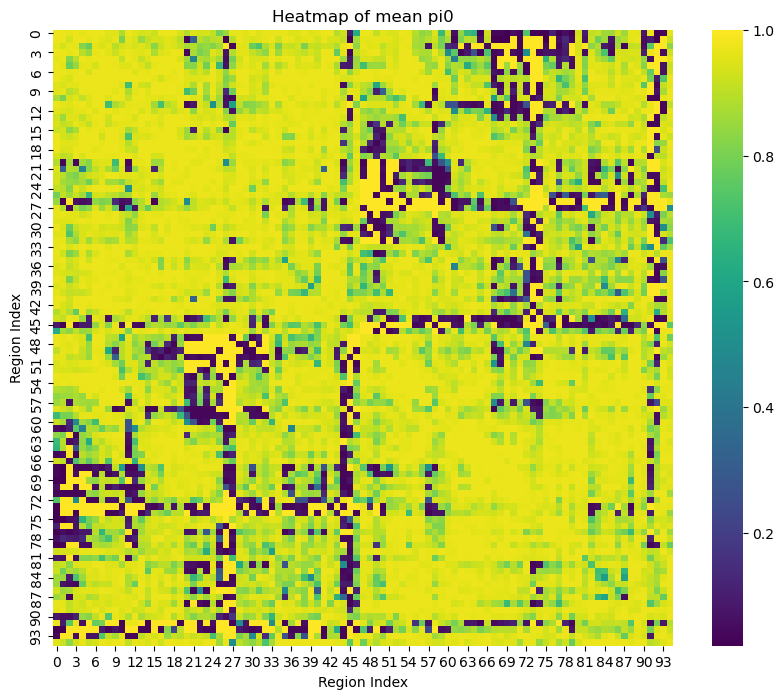

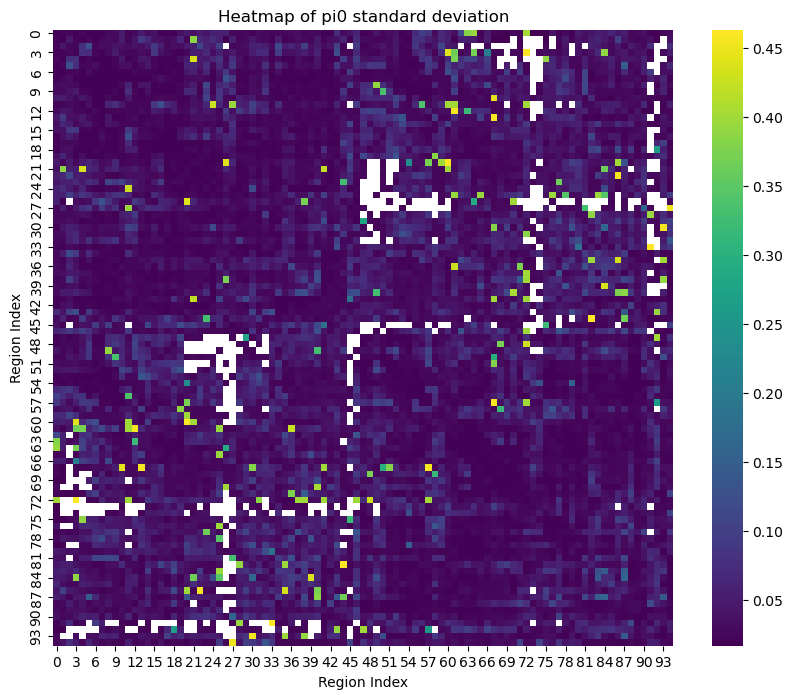

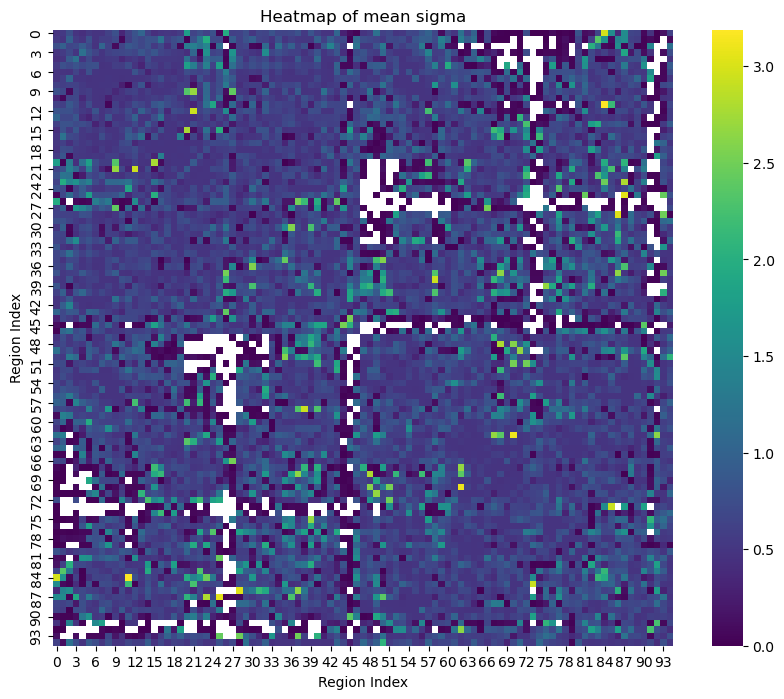

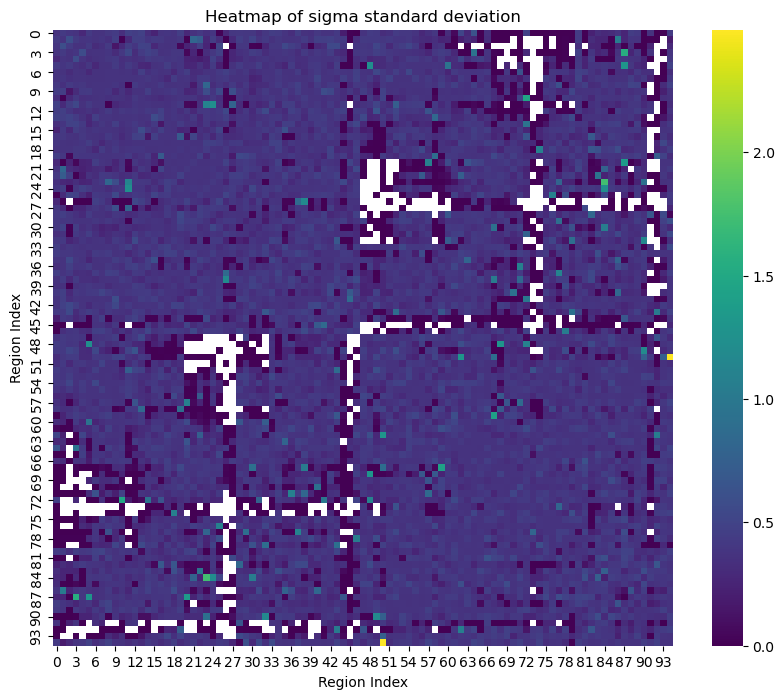

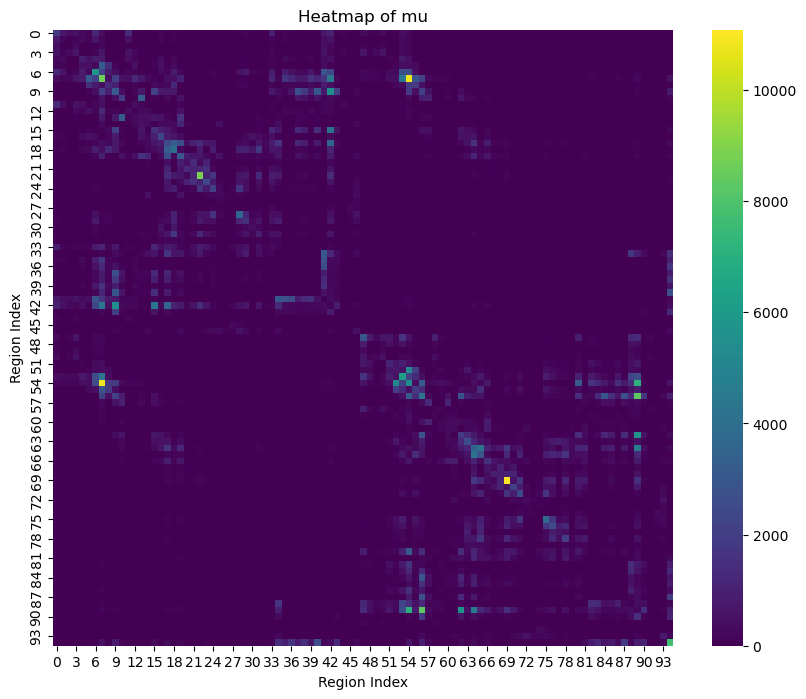

In [9]:
for p in ["pi0", "sigma"]:
    param = reconstruct_full_matrix([edge[p]["mean"] for edge in param_values], atlas_dim)
    plt.figure(figsize=(10, 8))
    sns.heatmap(param, cmap="viridis", cbar=True)
    plt.title(f"Heatmap of mean {p}")
    plt.xlabel("Region Index")
    plt.ylabel("Region Index")
    plt.show()

    param = reconstruct_full_matrix([edge[p]["sd"] for edge in param_values], atlas_dim)
    plt.figure(figsize=(10, 8))
    sns.heatmap(param, cmap="viridis", cbar=True)
    plt.title(f"Heatmap of {p} standard deviation")
    plt.xlabel("Region Index")
    plt.ylabel("Region Index")
    plt.show()

param = reconstruct_full_matrix([edge["mu"] for edge in param_values], atlas_dim)
plt.figure(figsize=(10, 8))
sns.heatmap(param, cmap="viridis", cbar=True)
plt.title(f"Heatmap of mu")
plt.xlabel("Region Index")
plt.ylabel("Region Index")
plt.show()

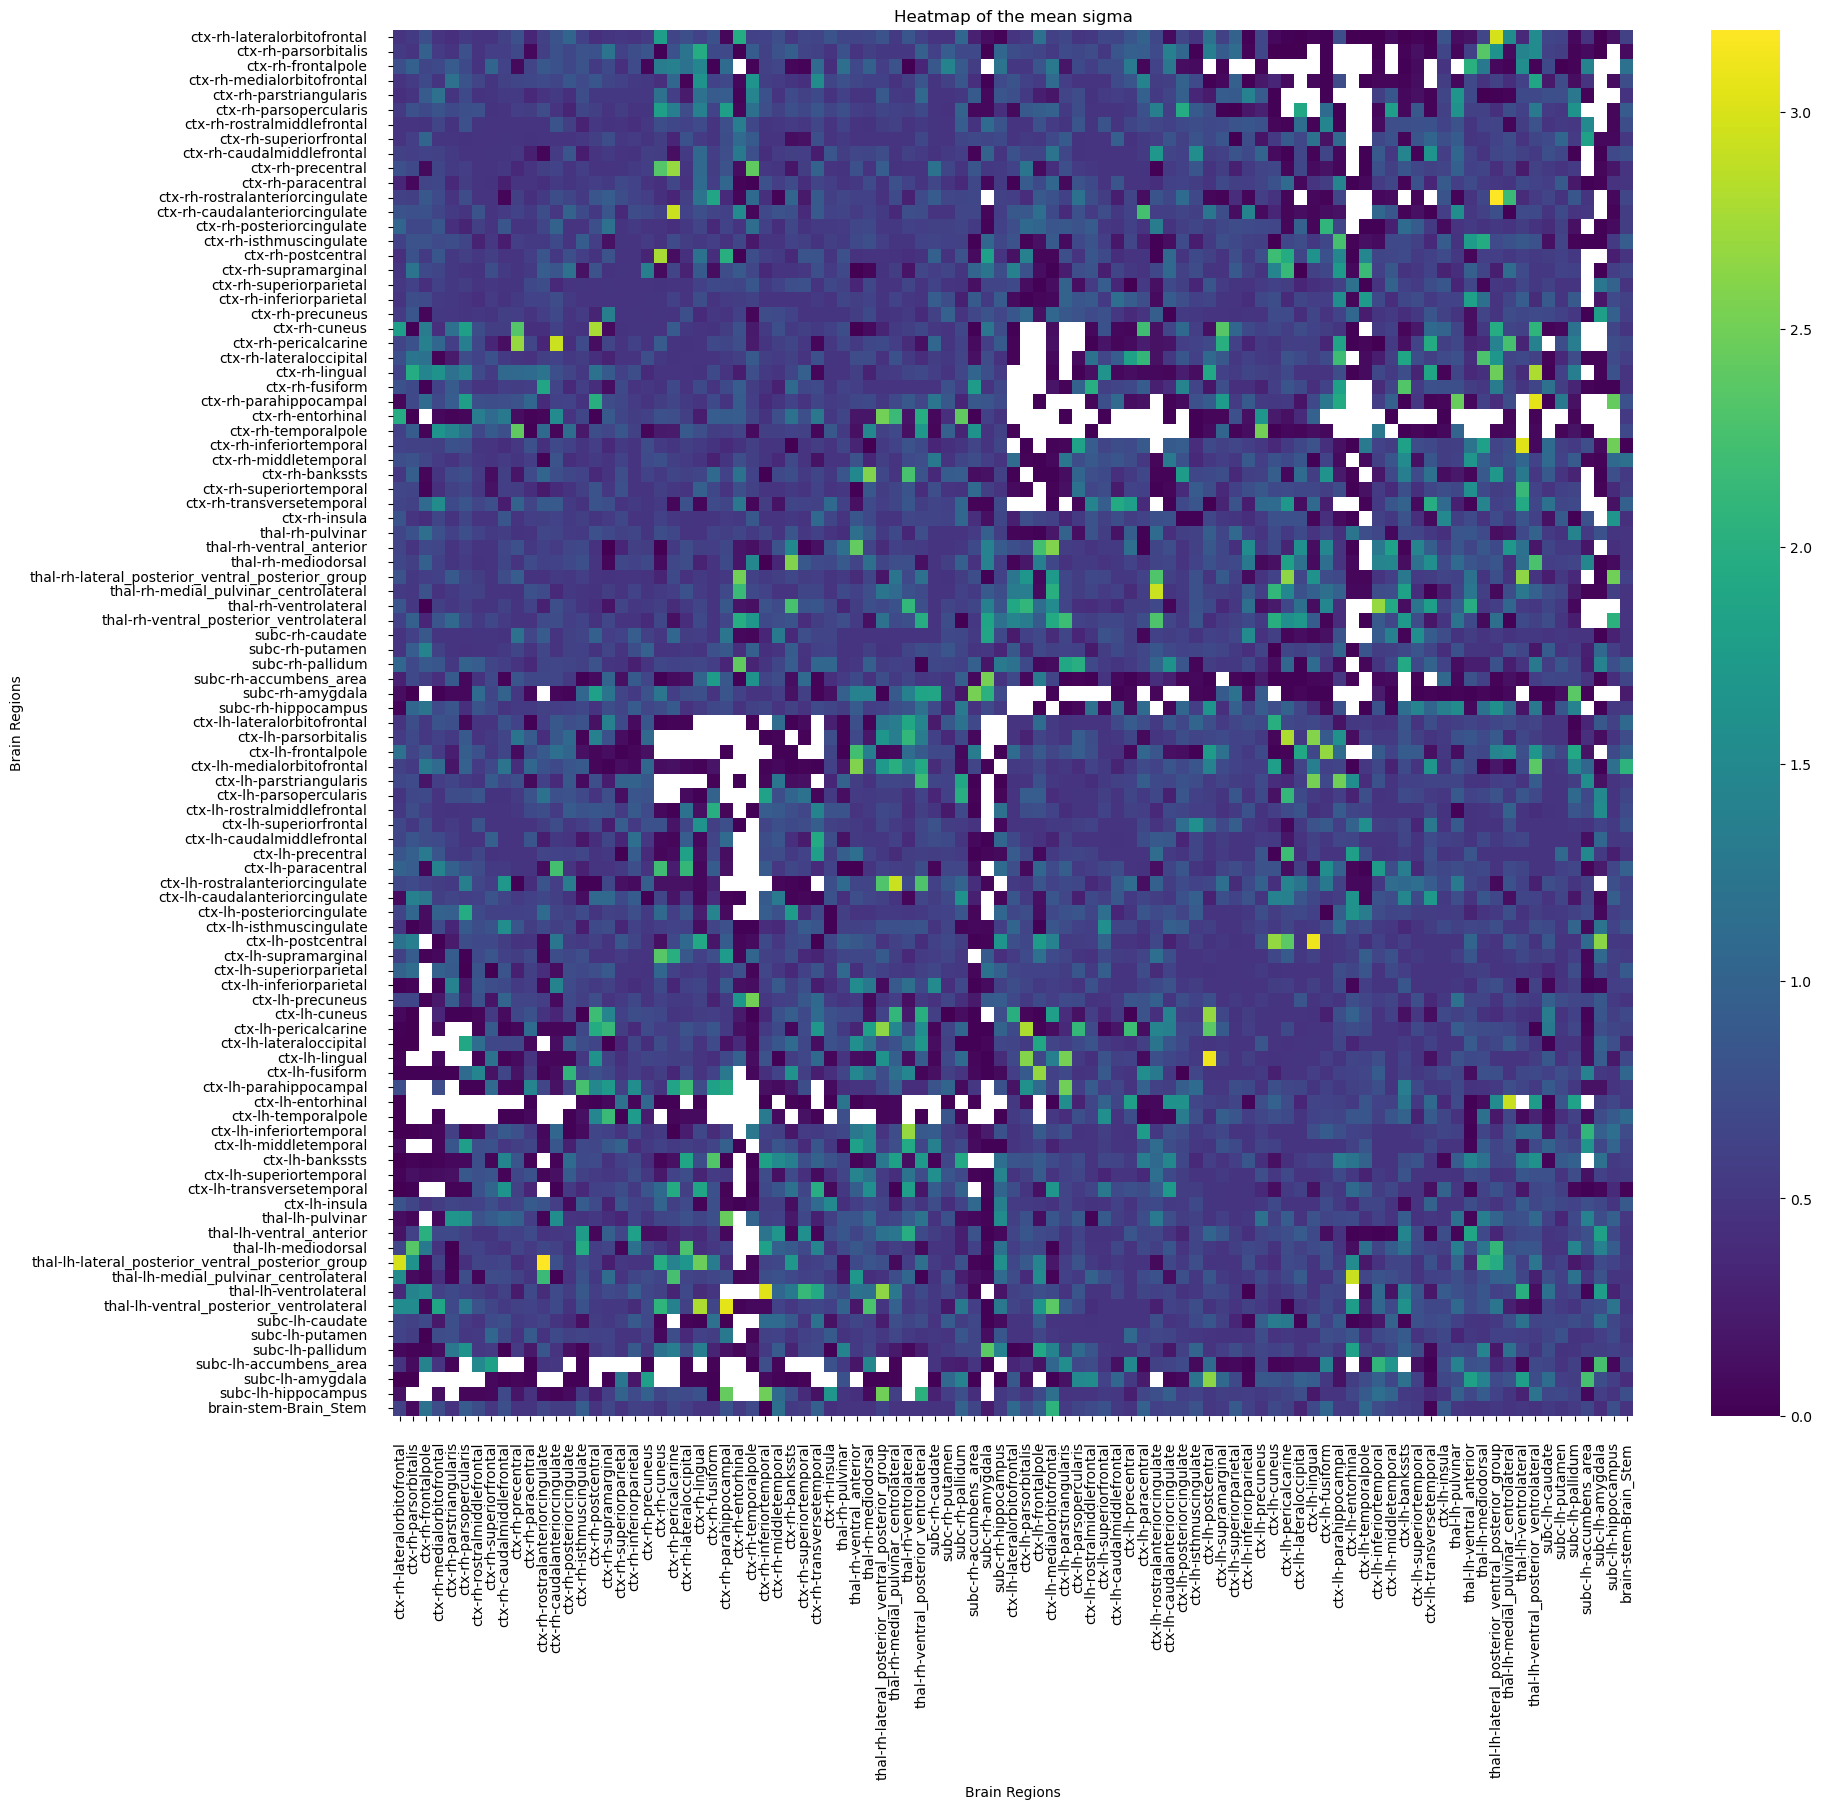

In [36]:
sigma = reconstruct_full_matrix([edge["sigma"]["mean"] for edge in param_values], atlas_dim)
 
# Plot the principal component as a heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(sigma, cmap='viridis')
plt.title(f'Heatmap of the mean sigma')
plt.xlabel('Brain Regions')
plt.ylabel('Brain Regions')
# Adjust y-ticks to move them further away from the heatmap
plt.yticks(ticks=np.arange(len(atlas_labels)) + 0.5, labels=atlas_labels, va='center', rotation=0)
plt.xticks(ticks=np.arange(len(atlas_labels)) + 0.5, labels=atlas_labels, rotation=90, ha='center')
plt.gca().tick_params(axis='y', pad=15)  # Move y-ticks further away
plt.gca().tick_params(axis='x', pad=15)  # Move x-ticks further away
plt.show()

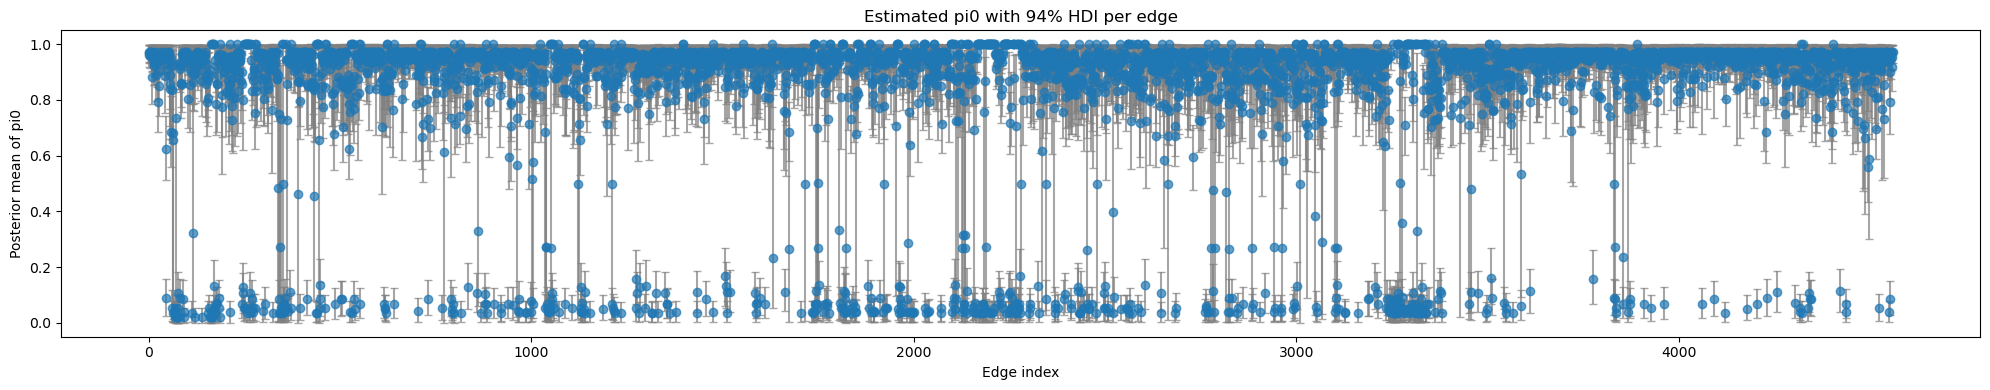

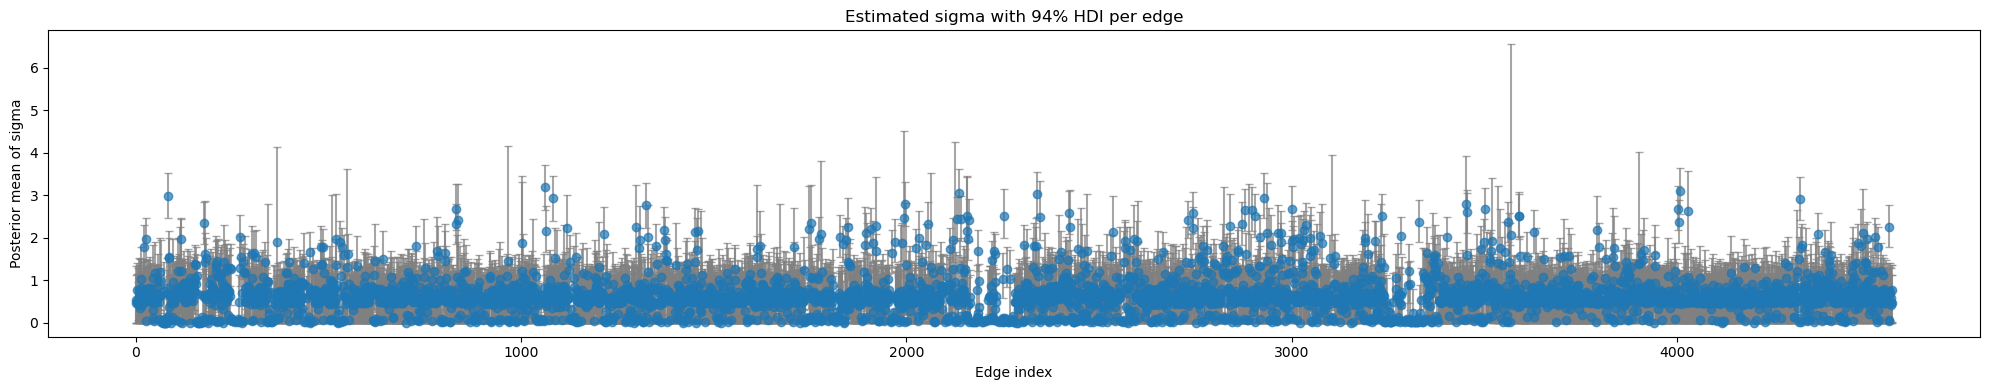

In [ ]:
def plot_hdi(param_values, param_name):
    import matplotlib.pyplot as plt
    import numpy as np

    # Extract values
    means = [res[param_name]["mean"] for res in param_values]
    lower = [res[param_name]["hdi_3%"] for res in param_values]
    upper = [res[param_name]["hdi_97%"] for res in param_values]

    # Convert to arrays for easier math
    means = np.array(means)
    lower = np.array(lower)
    upper = np.array(upper)

    # Compute asymmetric error bars
    yerr = np.vstack([means - lower, upper - means])
    # Some values in yerr are negative because lower and upper are zero but mean is nonzero (e.g 0.003), cast all negative values to zero
    yerr[yerr < 0] = 0
        
    # Plot
    plt.figure(figsize=(20, 4))
    x = np.arange(len(means))
    plt.errorbar(x, means, yerr=yerr, fmt="o", capsize=3, ecolor="gray", alpha=0.7)

    plt.xlabel("Edge index")
    plt.ylabel(f"Posterior mean of {param_name}")
    plt.title(f"Estimated {param_name} with 94% HDI per edge")
    plt.tight_layout()
    plt.show()


plot_hdi(param_values, "pi0")
plot_hdi(param_values, "sigma")

T-statistic: 12.9560, P-value: 4.950164141261e-38


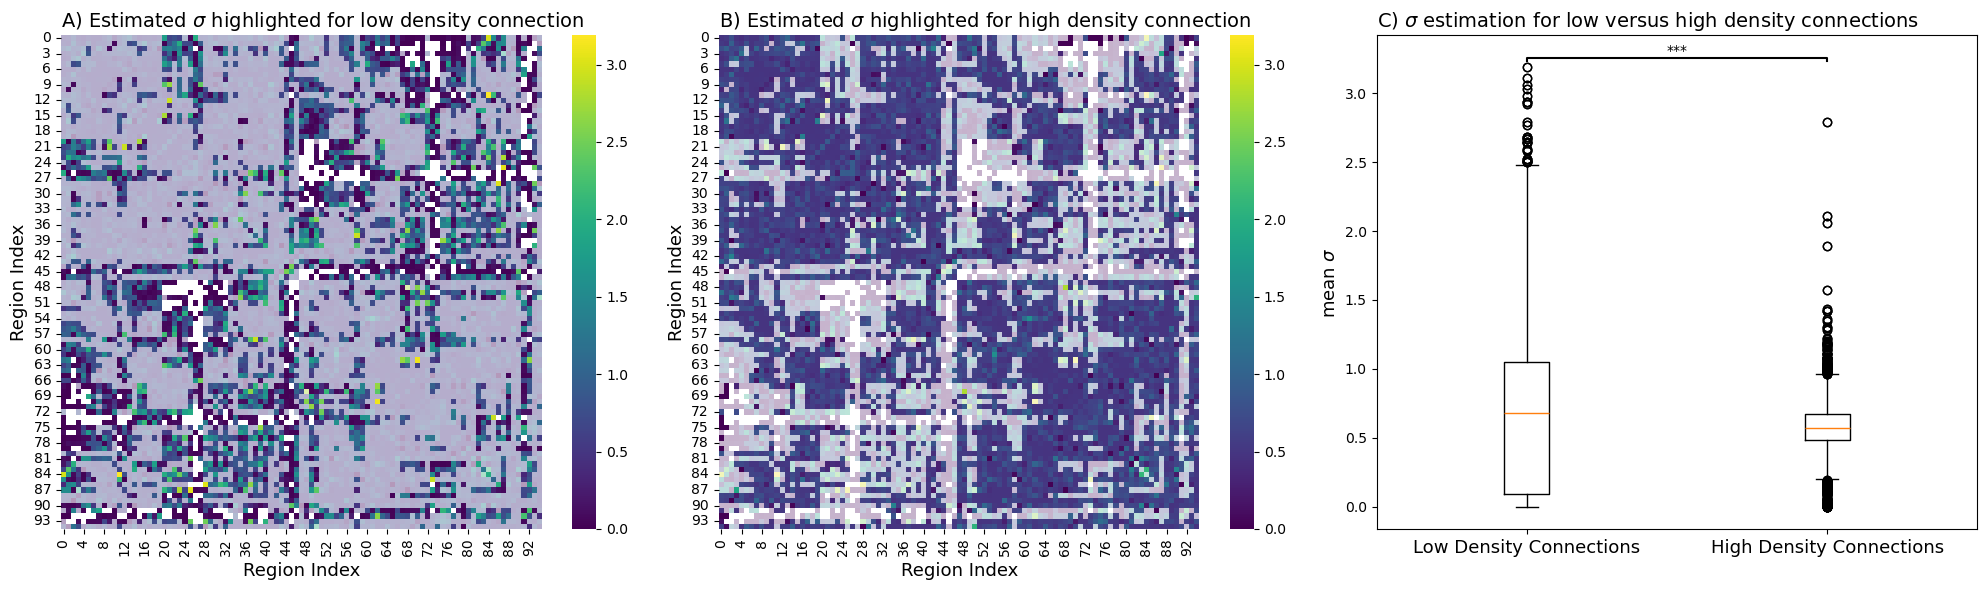

In [ ]:
from scipy.stats import ttest_ind

mask_h = density_matrix >= np.percentile(density_matrix[~np.isnan(density_matrix)], 40)
mask_l = density_matrix < np.percentile(density_matrix[~np.isnan(density_matrix)], 40)

alpha_mask_l = np.ones_like(sigma)
alpha_mask_l[mask_h] = (
    0.4  # make the voxels that should not be largely biased semi-transparent
)

alpha_mask_h = np.ones_like(sigma)
alpha_mask_h[mask_l] = (
    0.3  # make the voxels that should not be largely biased semi-transparent
)

# Perform a t-test comparing the estimated sigma values for low and high density connections
t_stat, p_value = ttest_ind(sigma[mask_l].flatten(), sigma[mask_h].flatten())
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.12e}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# Heatmap with alpha_mask
sns.heatmap(sigma, cmap="viridis", cbar=True, alpha=alpha_mask_l, ax=axes[0])
axes[0].set_title(
    r"A) Estimated $\sigma$ highlighted for low density connection",
    fontsize=14,
    loc="left",
)
axes[0].set_xlabel("Region Index", fontsize=13)
axes[0].set_ylabel("Region Index", fontsize=13)

# Heatmap with 1 - alpha_mask
sns.heatmap(sigma, cmap="viridis", cbar=True, alpha=alpha_mask_h, ax=axes[1])
axes[1].set_title(
    r"B) Estimated $\sigma$ highlighted for high density connection",
    fontsize=14,
    loc="left",
)
axes[1].set_xlabel("Region Index", fontsize=13)
axes[1].set_ylabel("Region Index", fontsize=13)

# Boxplot for low and high density connections
# Boxplot for low and high density connections
axes[2].boxplot(
    [sigma[mask_l].flatten(), sigma[mask_h].flatten()],
    tick_labels=["Low Density Connections", "High Density Connections"],
)
axes[2].set_xticklabels(
    ["Low Density Connections", "High Density Connections"], fontsize=13
)
axes[2].set_title(
    r"C) $\sigma$ estimation for low versus high density connections",
    fontsize=14,
    loc="left",
)
axes[2].set_ylabel(r"mean $\sigma$", fontsize=13)

# Add a line with *** to indicate statistical significance
x1, x2 = 1, 2  # positions of the two boxplots
y, h, col = (
    sigma[mask_l].max() + 0.05,
    0.02,
    "black",
)  # y position, height of the line, and color
axes[2].plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c=col)
axes[2].text((x1 + x2) * 0.5, y + h, "***", ha="center", va="bottom", color=col)

plt.tight_layout()
plt.show()

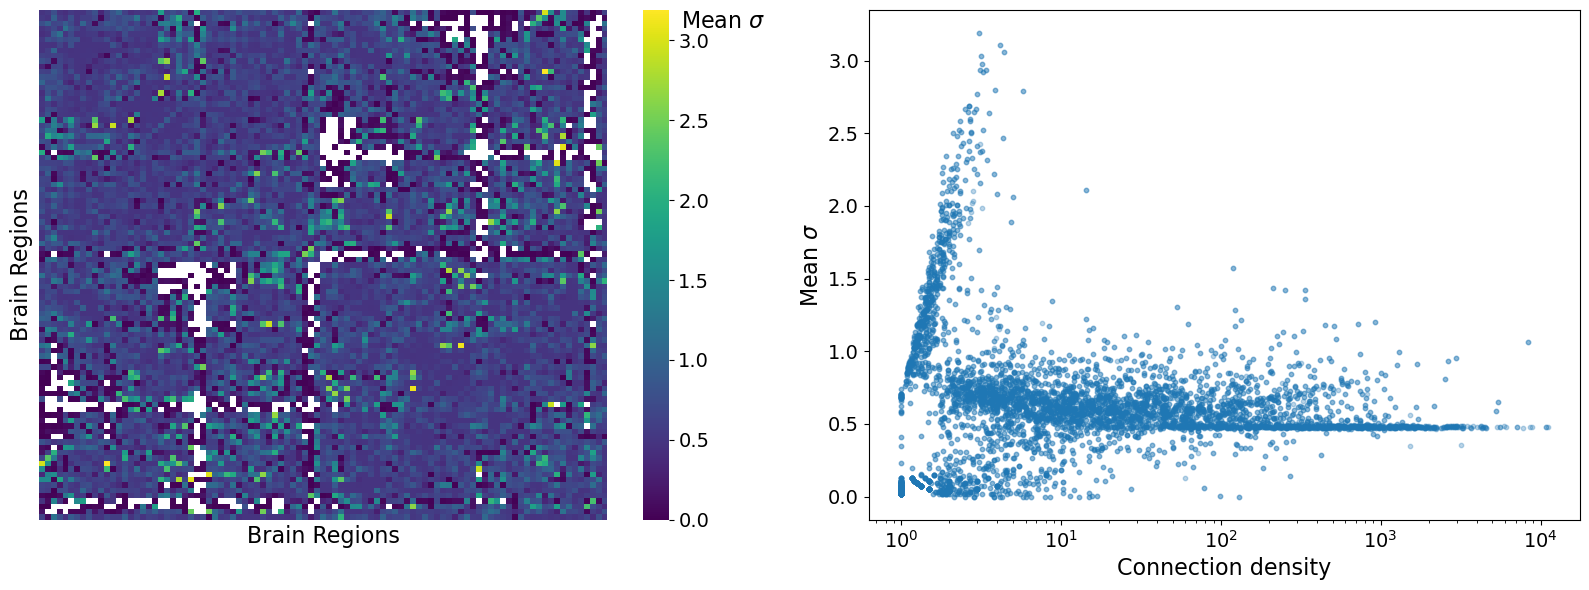

In [47]:
# Flatten sigma and density_matrix, mask out nan values in density_matrix
density_flat = density_matrix.flatten()
sigma_flat = sigma.flatten()

# Mask out nan values in density_matrix
mask = ~np.isnan(density_flat)
density_flat = density_flat[mask]
sigma_flat = sigma_flat[mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of sigma
sns.heatmap(sigma, cmap="viridis", cbar=True, ax=axes[0])
axes[0].set_xlabel("Brain Regions", fontsize=16)
axes[0].set_ylabel("Brain Regions", fontsize=16)
axes[0].set_xticks([])
axes[0].set_yticks([])
cbar = axes[0].collections[0].colorbar
cbar.set_label(r"Mean $\sigma$", labelpad=40, loc="top", rotation=0, fontsize=16)
cbar.ax.tick_params(labelsize=14)

# Scatter plot
axes[1].scatter(density_flat, sigma_flat, alpha=0.3, s=10)
axes[1].set_xlabel("Connection density", fontsize=16)
axes[1].set_ylabel(r"Mean $\sigma$", fontsize=16)
axes[1].set_xscale("log")
axes[1].tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

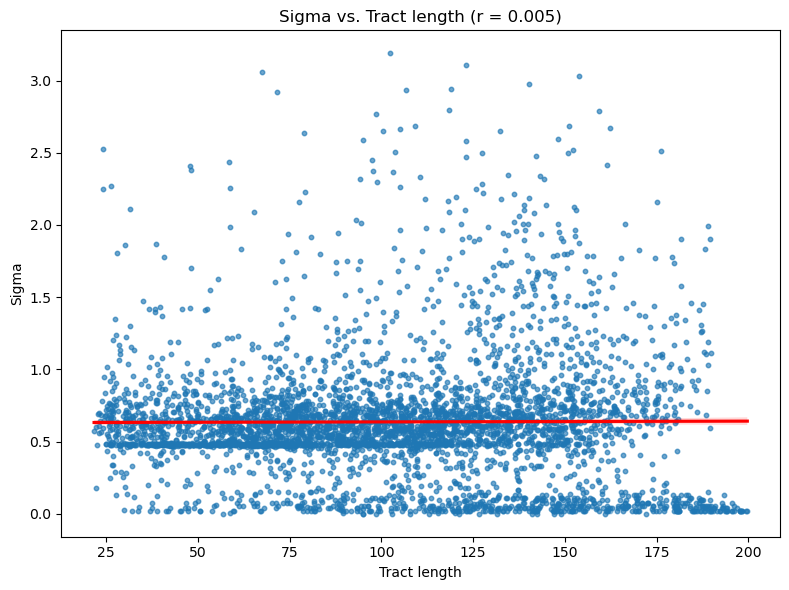

In [55]:
# Plot sigma as a function of tract length
length_flat = length_matrix.flatten()
sigma_flat = sigma.flatten()

# Keep only valid (non-NaN) and non-zero length entries
mask_len = (~np.isnan(length_flat)) & (~np.isnan(sigma_flat)) & (length_flat > 0)
length_valid = length_flat[mask_len]
sigma_valid = sigma_flat[mask_len]

# Compute Pearson correlation
corr = np.corrcoef(length_valid, sigma_valid)[0, 1]

plt.figure(figsize=(8, 6))
sns.regplot(x=length_valid, y=sigma_valid, scatter_kws={"s": 10, "alpha": 0.4}, line_kws={"color": "red"})
plt.xlabel("Tract length")
plt.ylabel("Sigma")
plt.title(f"Sigma vs. Tract length (r = {corr:.3f})")
plt.tight_layout()
plt.show()

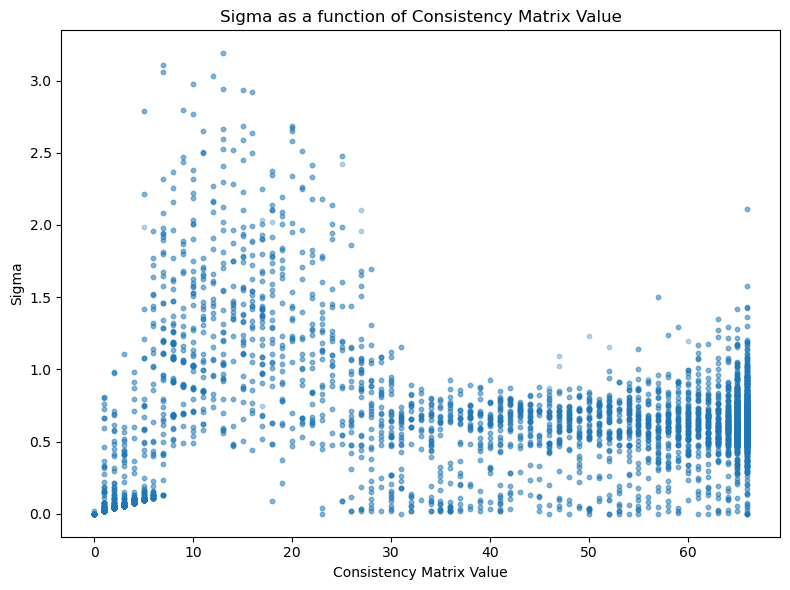

In [56]:
# Flatten sigma and consistency_matrix, mask out nan values in consistency_matrix
consistency_flat = consistency_matrix.flatten()
sigma_flat = sigma.flatten()

# Mask out nan values (if any) in consistency_matrix
mask = ~np.isnan(consistency_flat)
consistency_flat = consistency_flat[mask]
sigma_flat = sigma_flat[mask]

plt.figure(figsize=(8, 6))
plt.scatter(consistency_flat, sigma_flat, alpha=0.3, s=10)
plt.xlabel("Consistency Matrix Value")
plt.ylabel("Sigma")
plt.title("Sigma as a function of Consistency Matrix Value")
plt.tight_layout()
plt.show()

<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_5797/3855423854.py:41: SyntaxWarning: invalid escape sequence '\p'
  "B) Estimated $\pi_0$ highlighted for low consistency connections\npresent in at least one subject",


nan versus high consistency: T-statistic: -1.9558, P-value: 5.053768269361e-02
nan versus low consistency: T-statistic: 18.3510, P-value: 3.246035012223e-72
low versus high consistency: T-statistic: -62.2936, P-value: 0.000000000000e+00


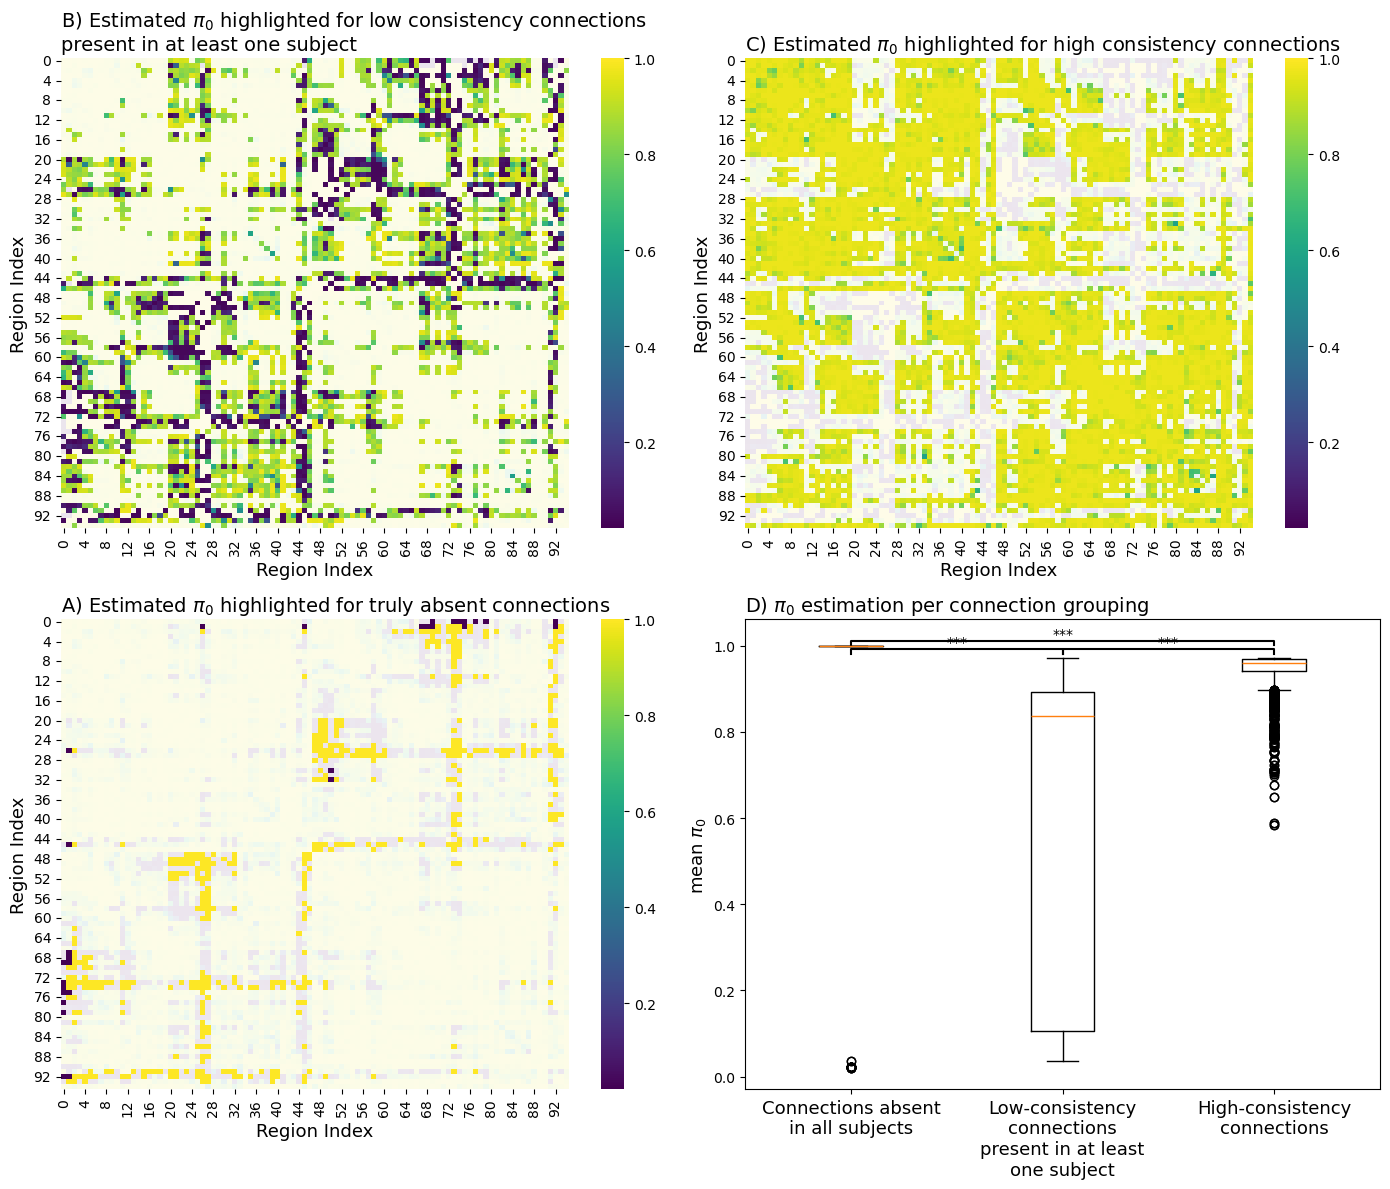

In [50]:
threshold = np.percentile(consistency_matrix[consistency_matrix > 0], 40)
pi0 = reconstruct_full_matrix([edge["pi0"]["mean"] for edge in param_values], atlas_dim)
nan_mask = np.isnan(density_matrix)
low_cons = (consistency_matrix <= threshold) & (~nan_mask)
high_cons = consistency_matrix > threshold

alpha_mask_lc = np.ones_like(pi0)
alpha_mask_hc = np.ones_like(pi0)
alpha_mask_na = np.ones_like(pi0)
alpha_mask_na[~nan_mask] = 0.1
alpha_mask_hc[~low_cons] = 0.1
alpha_mask_lc[~high_cons] = 0.1

# Perform a t-test comparing the estimated sigma values for low and high density connections
t_stat, p_value = ttest_ind(pi0[nan_mask].flatten(), pi0[high_cons].flatten())
print(
    f"nan versus high consistency: T-statistic: {t_stat:.4f}, P-value: {p_value:.12e}"
)

t_stat, p_value = ttest_ind(pi0[nan_mask].flatten(), pi0[low_cons].flatten())
print(f"nan versus low consistency: T-statistic: {t_stat:.4f}, P-value: {p_value:.12e}")

t_stat, p_value = ttest_ind(pi0[low_cons].flatten(), pi0[high_cons].flatten())
print(
    f"low versus high consistency: T-statistic: {t_stat:.4f}, P-value: {p_value:.12e}"
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
# Heatmap with alpha_mask
sns.heatmap(pi0, cmap="viridis", cbar=True, alpha=alpha_mask_na, ax=axes[1, 0])
axes[1, 0].set_title(
    r"A) Estimated $\pi_0$ highlighted for truly absent connections",
    fontsize=14,
    loc="left",
)
axes[1, 0].set_xlabel("Region Index", fontsize=13)
axes[1, 0].set_ylabel("Region Index", fontsize=13)

sns.heatmap(pi0, cmap="viridis", cbar=True, alpha=alpha_mask_hc, ax=axes[0, 0])
axes[0, 0].set_title(
    "B) Estimated $\pi_0$ highlighted for low consistency connections\npresent in at least one subject",
    fontsize=14,
    loc="left",
)
axes[0, 0].set_xlabel("Region Index", fontsize=13)
axes[0, 0].set_ylabel("Region Index", fontsize=13)

# Heatmap with 1 - alpha_mask
sns.heatmap(pi0, cmap="viridis", cbar=True, alpha=alpha_mask_lc, ax=axes[0, 1])
axes[0, 1].set_title(
    r"C) Estimated $\pi_0$ highlighted for high consistency connections",
    fontsize=14,
    loc="left",
)
axes[0, 1].set_xlabel("Region Index", fontsize=13)
axes[0, 1].set_ylabel("Region Index", fontsize=13)

# Boxplot
axes[1, 1].boxplot(
    [pi0[nan_mask].flatten(), pi0[low_cons].flatten(), pi0[high_cons].flatten()]
)
axes[1, 1].set_xticklabels(
    [
        "Connections absent\nin all subjects",
        "Low-consistency\nconnections\npresent in at least\none subject",
        "High-consistency\nconnections",
    ],
    fontsize=13,
)
axes[1, 1].set_title(
    r"D) $\pi_0$ estimation per connection grouping", fontsize=14, loc="left"
)
axes[1, 1].set_ylabel(r"mean $\pi_0$", fontsize=13)

# Add a line with *** to indicate statistical significance
x1, x2 = 1, 3  # positions of the two boxplots
y, h, col = (
    pi0[~nan_mask].max() + 0.03,
    0.01,
    "black",
)  # y position, height of the line, and color
axes[1, 1].plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c=col)
axes[1, 1].text((x1 + x2) * 0.5, y + h, f"***", ha="center", va="bottom", color=col)

x1, x2 = 2, 3  # positions of the two boxplots
y, h, col = (
    pi0[~nan_mask].max() + 0.01,
    0.01,
    "black",
)  # y position, height of the line, and color
axes[1, 1].plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c=col)
axes[1, 1].text((x1 + x2) * 0.5, y + h, f"***", ha="center", va="bottom", color=col)

x1, x2 = 1, 2  # positions of the two boxplots
y, h, col = (
    pi0[~nan_mask].max() + 0.01,
    0.01,
    "black",
)  # y position, height of the line, and color
axes[1, 1].plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c=col)
axes[1, 1].text((x1 + x2) * 0.5, y + h, f"***", ha="center", va="bottom", color=col)

plt.tight_layout()
plt.show()